# 00 - Raw duty sweep characterization

## Purpose

This notebook is the first in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. The
series starts from raw ADC readings and derives every quantity in the open.
Later notebooks compare these derivations against what the firmware
computes on the servo.

This notebook has three jobs:

1. Document the measurement chain and the constants that convert ADC
   readings into volts and amperes (section 2).
2. Measure the offset, noise, and limits of each raw channel (section 5).
3. Check that the data follows the expected brushed DC motor behavior
   (section 6).

The dataset is two test series with identical method, one powered from a
5 V USB source and one from a 2-cell lithium battery.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain:

- A brushed DC motor driven by an H-bridge with 20 kHz PWM. The controller
  commands **duty**. Duty is the fraction of each PWM period during which
  the bridge applies the supply across the motor. Duty is signed. Negative
  duty drives the opposite direction.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. The pot wiper connects
  directly to an ADC pin, so position readings convert to volts at the
  wiper with no divider. Converting wiper volts to output angle requires an
  angle calibration, which a later notebook derives, so position stays in
  wiper volts here.
- A 33 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included.
- Both motor terminals are read through 20 kOhm / 10 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`.
- The controller streams one frame of raw ADC samples per 50 us control
  period (20,000 samples per second). Every frame carries a CRC. Corrupted
  frames are dropped and counted, so corruption turns into missing samples
  (verified in section 4).

Power for the two test series:

- **USB series**: a laptop USB port. The voltage reaching the motor is
  measured in section 6.2. It is well below the nominal 5 V and drops
  further under load.
- **Battery series**: a 2-cell lithium battery, nominal 7.4 V, measured in
  section 6.2. This is above the 4.8 to 6 V range usually quoted for
  SG90-class servos, so the full-duty steps in the battery series stress
  the mechanism beyond its usual rating.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM period | 1200 timer ticks |
| Duty encoding | signed, 32767 = 100% |
| Current sampling threshold | 240 timer ticks = 20% duty |
| Voltage sampling threshold | 300 timer ticks = 25% duty |

Two caveats:

- The ADC reference is the chip's VDD supply. The 3.300 V figure is the
  design value, and the actual VDD of this unit was not measured. Every
  voltage below scales linearly with the true VDD, so one future
  measurement of VDD rescales everything by one factor.
- The divider, shunt, and gain are design values. Component tolerances
  were not measured, and absolute voltages and currents carry them.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_PERIOD_TICKS = 1200     # timer ticks per PWM period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
V_TERM_PER_COUNT = V_ADC_PER_COUNT * (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt

pd.DataFrame([
    {"channel": "pot wiper", "factor": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"channel": "motor terminal", "factor": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"channel": "motor current", "factor": A_PER_COUNT * 1e3, "unit": "mA per count"},
]).set_index("channel").round(4)


,factor,unit
channel,,
pot wiper,0.8057,mV per count
motor terminal,2.4170,mV per count
motor current,1.6276,mA per count


## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/sg90/`,
ten per supply. One recording contains 41 segments, captured back to back:

- **Segment 0** is a one-second baseline with the motor undriven. It
  measures the noise floor of each channel and the current amplifier's
  offset.
- **Segments 1 to 40** are constant-duty drive steps, duty from 5% to 100%
  in 5% increments, first forward then reverse. Each step drives for 80 ms
  with full-rate capture, followed by 500 ms of rest. Before each step the
  servo is repositioned at 15% duty toward the far end of travel, so there
  is room to accelerate.

Between recordings the servo was rebooted and rested for one minute, so
every recording starts from the same software state and similar thermal
state. Both series follow this method exactly. The only difference is the
supply.

**Braking between steps.** After each step's capture window closes, the
sweep tool commands a 0.25% duty with slow-decay switching, which
short-circuits the motor winding for 99.75% of every PWM period and brakes
the motor to rest. The braking happens after the capture window, so the
recorded data is unaffected.

**Data acceptance.** Any recording in which the host counted even one
dropped frame was discarded and re-run. Section 4 re-verifies this from
the data itself.

Each row of a recording is one 50 us sample: segment number, commanded
duty, tick counter, the firmware's sampling-validity flag (section 5.3),
and the raw channels (position, current, current trough, applied duty,
both motor terminals).


In [2]:
# Load both series. The absolute prefix becomes a relative path once
# this notebook lands in notebooks/ next to the data.
TELEMETRY = Path("telemetry/sg90")

def load_recording(rec_dir):
    # One recording = sweep.csv.gz (per-tick samples) + meta.json (settings).
    # Derived columns: duty_pct (signed percent), t_ms (ms since start).
    df = pd.read_csv(rec_dir / "sweep.csv.gz")
    meta = json.loads((rec_dir / "meta.json").read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["t_ms"] = (df["tick"] - df["tick"].iloc[0]) / (TICK_HZ / 1000)
    return df, meta

def load_series(base):
    recs = {}
    for d in sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
        recs[d.name] = load_recording(d)
    return recs

usb = load_series(TELEMETRY / "usb")
batt = load_series(TELEMETRY / "2s")
pd.DataFrame({"recordings": [len(usb), len(batt)]}, index=["usb", "2s battery"])


,recordings
usb,10
2s battery,10


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. One frame
carries 16 consecutive samples, so a dropped frame appears as a 16-tick
jump in the tick column. The table below recomputes the missing-sample
count for every recording from the tick column.


In [3]:
def integrity(recs):
    rows = []
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
    return pd.DataFrame(rows)

pd.concat([
    integrity(usb).assign(series="usb"),
    integrity(batt).assign(series="2s battery"),
], ignore_index=True)


,recording,samples,segments,missing_samples,series
0,capture-1,84000,41,0,usb
1,capture-2,84000,41,0,usb
2,capture-3,84000,41,0,usb
3,capture-4,84000,41,0,usb
4,capture-5,84000,41,0,usb
5,capture-6,84000,41,0,usb
6,capture-7,84000,41,0,usb
7,capture-8,84000,41,0,usb
8,capture-9,84000,41,0,usb
9,capture-10,84000,41,0,usb


Every recording holds 84,000 samples in 41 segments with zero missing
samples.

## 5. Channel characterization

### 5.1 Position

The position channel is the pot wiper voltage. The baseline segment of
each recording gives its noise floor at rest. The repositioning move
before the baseline ends with the motor unpowered, and at battery voltage
the mechanism can still be coasting to rest when the capture starts. The
code below measures this residual motion. It dies out within the first
100 ms, so the noise statistics drop the first 200 ms of the one-second
baseline and use the settled remainder.


In [4]:
rows = []
for series, recs in [("usb", usb), ("2s battery", batt)]:
    for name, (df, _) in recs.items():
        base = df[df["seg"] == 0]["pos"].to_numpy() * V_ADC_PER_COUNT
        settled = base[len(base) // 5:]
        rows.append({
            "series": series,
            "peak_dev_mV": np.max(np.abs(settled - np.median(settled))) * 1e3,
            "std_mV": np.std(settled) * 1e3,
            # residual coast from the repositioning move: how far the
            # first 100 ms sits from the settled level
            "coast_first_100ms_mV": abs(np.median(base[:2000])
                                        - np.median(settled)) * 1e3,
        })
pd.DataFrame(rows).groupby("series").agg(["mean", "max"]).round(2)


peak_dev_mV       std_mV       coast_first_100ms_mV       
                  mean   max   mean   max                 mean    max
series                                                               
2s battery        6.53  7.25   1.62  1.74                 7.86  15.31
usb               6.93  8.06   1.71  1.90                 0.24   0.81

The rest noise is under a few millivolts at the wiper (one ADC count
is 0.81 mV). Section 6.1 uses this bound to decide whether a drive step
produced real motion.

### 5.2 Current offset

The bridge is disabled during the baseline, so no current flows through
the shunt and the baseline reading is the amplifier's output offset. It is
measured below from every baseline segment of both series.


In [5]:
rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    offs = [df[df["seg"] == 0]["current_raw"].mean() for df, _ in recs.values()]
    off_v = np.mean(offs) * V_ADC_PER_COUNT
    rows.append({
        "series": label,
        "offset_mV": off_v * 1e3,
        "offset_mA_equivalent": off_v / (AMP_GAIN * SHUNT_OHM) * 1e3,
        "recording_spread_mV": np.std(offs) * V_ADC_PER_COUNT * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2)


,offset_mV,offset_mA_equivalent,recording_spread_mV
series,,,
usb,84.44,170.58,0.37
2s battery,84.00,169.70,0.40


The offset is stable to a fraction of a millivolt across ten
reboot-separated recordings and agrees between the two series. It is
large, roughly 170 mA equivalent, so it must be subtracted before current
readings mean anything. Later notebooks subtract this measured value.

### 5.3 Fixed-phase sampling and the validity thresholds

The ADC samples current and terminal voltage once per PWM period, at a
fixed point inside the period. When the duty is high, that point falls
inside the ON portion and the sample reflects the driven state. When the
duty is low, the ON portion ends before the sampling point and the sample
reads the OFF state.

The firmware stamps every sample with a validity flag. Current samples
are marked valid when the ON portion is at least 240 of the 1200 timer
ticks (20% duty), terminal voltage samples at 300 ticks (25% duty). The
figure below shows the driven terminal's raw samples at three duty
levels, then checks where the recorded flag flips.


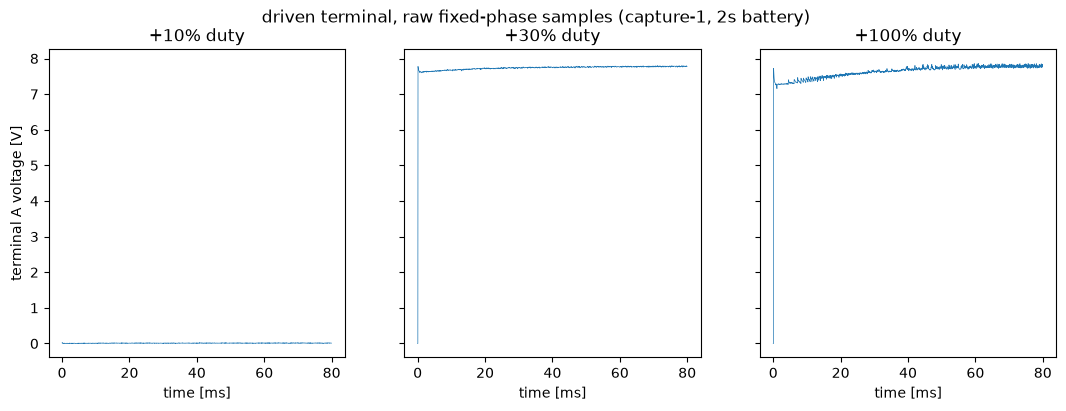

,recordings,distinct_flip_points,invalid_up_to_pct,valid_from_pct
series,,,,
usb,10,1,15.0,20.0
2s battery,10,1,15.0,20.0


In [6]:
name, (df, meta) = next(iter(batt.items()))
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, pct in zip(axes, [10, 30, 100]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (TICK_HZ / 1000)
    ax.plot(t, seg["vmotor_a"] * V_TERM_PER_COUNT, lw=0.5)
    ax.set_title(f"+{pct}% duty")
    ax.set_xlabel("time [ms]")
axes[0].set_ylabel("terminal A voltage [V]")
fig.suptitle(f"driven terminal, raw fixed-phase samples ({name}, 2s battery)")
plt.show()

# Where does the recorded validity flag flip? Checked in every recording
# of both series.
rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    flips = set()
    for df, _ in recs.values():
        v = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid_frac=("window_valid", "mean"))
        v["mag"] = v["d"].abs().round()
        flips.add((v[v.valid_frac <= 0.5]["mag"].max(),
                   v[v.valid_frac > 0.5]["mag"].min()))
    rows.append({
        "series": label,
        "recordings": len(recs),
        "distinct_flip_points": len(flips),
        "invalid_up_to_pct": max(h for h, _ in flips),
        "valid_from_pct": min(l for _, l in flips),
    })
pd.DataFrame(rows).set_index("series")


At +100% duty the sample lands in the ON portion every period and
reads near the supply voltage. At +30% it still catches the ON portion. At
+10% it reads near zero volts because the sampling instant misses the
short ON portion. The motor still receives its share of the supply during
that step, and the position data in section 6.1 shows the servo moving.

The recorded flag flips between the 15% and 20% duty steps in every
recording of both series, consistent with the configured 240-tick current
threshold. This imposes two rules on everything below:

- Current and terminal voltage readings are used only where the validity
  flag is set. Terminal voltage is additionally restricted to 25% duty and
  above, the stricter configured threshold.
- Below those thresholds the position channel is the only trusted channel.
  The pot wiper is sampled directly, outside the PWM window, so position
  has no such limit.

## 6. Results

### 6.1 Motion threshold

For each drive step, net travel is the difference between the median of
the last 20 and the first 20 position samples (medians so a single noise
spike cannot fake motion). This is compared against the rest-noise band
from section 5.1. One complication needs handling. Each drive step begins
shortly after a repositioning move, and the mechanism can still be
coasting from that move when the step begins (section 5.1 measures this in
the baselines). Drive-produced motion follows the commanded direction.
Residual coast follows the repositioning move, which by construction of
the test runs opposite the drive direction. So besides the per-step
scatter, the table pools travel aligned with the drive direction across
all recordings.


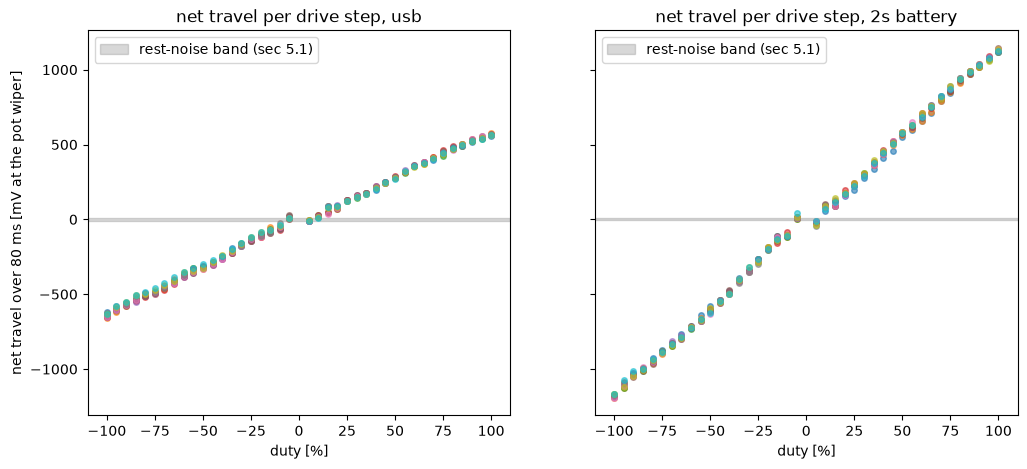

usb             2s battery            
               mean   std count       mean   std count
duty_mag_pct                                          
5.0           -11.1   6.3    20      -17.1  12.0    20
10.0           35.8  19.5    20       96.2  16.8    20
15.0           72.7  18.7    20      120.6  19.1    20
20.0           92.9  14.8    20      182.7  14.1    20
25.0          130.8   9.2    20      250.8  27.0    20

In [7]:
def step_travel(df):
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT * 1e3   # mV at the wiper
        out.append({
            "duty_pct": seg["duty_pct"].iloc[0],
            "travel_mV": np.median(p[-20:]) - np.median(p[:20]),
        })
    return pd.DataFrame(out)

def rest_band_mV(df):
    base = df[df["seg"] == 0]["pos"].to_numpy() * V_ADC_PER_COUNT * 1e3
    settled = base[len(base) // 5:]
    return np.max(np.abs(settled - np.median(settled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, recs, title in [(axes[0], usb, "usb"), (axes[1], batt, "2s battery")]:
    band = 0.0
    for name, (df, meta) in recs.items():
        tr = step_travel(df)
        band = max(band, rest_band_mV(df))
        ax.plot(tr["duty_pct"], tr["travel_mV"], "o", ms=4, alpha=0.6)
    ax.axhspan(-band, band, color="grey", alpha=0.3,
               label="rest-noise band (sec 5.1)")
    ax.set_xlabel("duty [%]")
    ax.set_title(f"net travel per drive step, {title}")
    ax.legend(loc="upper left")
axes[0].set_ylabel("net travel over 80 ms [mV at the pot wiper]")
plt.show()

# Drive-aligned travel by |duty| in mV; positive = moved in the
# commanded direction.
tables = {}
for label, recs in [("usb", usb), ("2s battery", batt)]:
    allt = pd.concat([step_travel(df) for df, _ in recs.values()])
    allt["aligned_mV"] = allt["travel_mV"] * np.sign(allt["duty_pct"])
    tables[label] = (allt.assign(duty_mag_pct=np.abs(allt["duty_pct"]).round())
                         .groupby("duty_mag_pct")["aligned_mV"]
                         .agg(["mean", "std", "count"]).head(5))
pd.concat(tables, axis=1).round(1)


Findings:

- At 10% duty the servo moves on both supplies. The mean aligned travel is
  roughly +36 mV per 80 ms step on USB and +95 mV on battery, far outside
  the rest-noise band, in the commanded direction, in every recording.
- At 5% duty the aligned travel is slightly negative with a tight spread on
  both supplies. Drive cannot produce motion opposite the command. Residual
  coast can, and its direction opposes the drive direction here by
  construction. The 5% steps are therefore consistent with zero
  drive-produced motion.

So the motion threshold of this unit lies between 5% and 10% duty on both
supplies.

The two supplies together narrow this further. If the threshold is a fixed
voltage (the voltage needed to overcome friction), the relevant axis is
duty times the supply voltage. Section 6.2 measures the light-load supplies
at 4.47 V (USB) and 7.75 V (battery). The USB 5% step applies about 0.22 V
and does not move. The battery 5% step applies about 0.39 V and does not
move. The USB 10% step applies about 0.45 V and moves. The minimum voltage
that produces motion therefore lies between 0.39 and 0.45 V for this unit.
A single supply brackets this a factor of two wide. The second supply
squeezes the bracket to about 15%. Why a DC motor needs a minimum voltage
to start moving is a friction question, taken up in a later notebook.

### 6.2 Supply voltage under load

The board has no dedicated ADC channel for the supply. It has the two motor
terminals. While the bridge drives, the driven terminal connects to the
supply through the high-side switch, so its voltage is the supply minus the
switch drop. The estimate below takes, per drive step, the 90th percentile
of the driven terminal's valid samples (terminal A when driving forward,
terminal B in reverse), restricted to duty at or above the 25% voltage
threshold. Steps below the threshold have no valid voltage samples and are
absent from the figure.


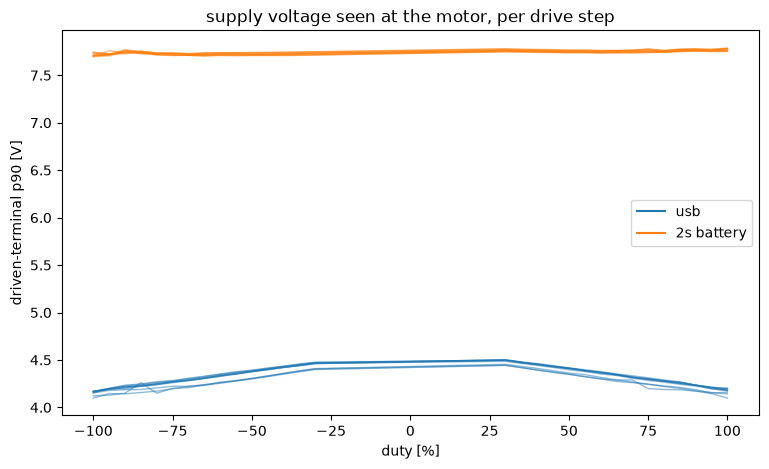

,light_load_V,full_duty_V,drop_mV
series,,,
usb,4.47,4.16,302.97
2s battery,7.75,7.74,3.23


In [8]:
def step_supply(df):
    # Supply estimate per drive step: p90 of the driven terminal, valid
    # samples at >= 25% duty only.
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        d = seg["duty_pct"].iloc[0]
        if abs(d) < 25:
            continue
        v = seg[seg["window_valid"] == 1]
        if len(v) < 100:
            continue
        term = v["vmotor_a"] if d > 0 else v["vmotor_b"]
        out.append({"duty_pct": d,
                    "supply_V": term.quantile(0.9) * V_TERM_PER_COUNT})
    return pd.DataFrame(out).sort_values("duty_pct")

fig, ax = plt.subplots(figsize=(9, 5))
for recs, color, label in [(usb, "tab:blue", "usb"),
                           (batt, "tab:orange", "2s battery")]:
    for name, (df, _) in recs.items():
        r = step_supply(df)
        ax.plot(r["duty_pct"], r["supply_V"], "-", lw=1, alpha=0.5, color=color)
    ax.plot([], [], "-", color=color, label=label)
ax.set_xlabel("duty [%]")
ax.set_ylabel("driven-terminal p90 [V]")
ax.set_title("supply voltage seen at the motor, per drive step")
ax.legend()
plt.show()

rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    hi, lo = [], []
    for df, _ in recs.values():
        r = step_supply(df)
        lo.append(r[r["duty_pct"].abs() >= 95]["supply_V"].mean())
        hi.append(r[r["duty_pct"].abs() <= 30]["supply_V"].mean())
    rows.append({
        "series": label,
        "light_load_V": np.mean(hi),
        "full_duty_V": np.mean(lo),
        "drop_mV": (np.mean(hi) - np.mean(lo)) * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2)


Findings:

- The USB series delivers about 4.5 V at light load, already well below
  the nominal 5 V, and drops by roughly another 0.3 V as duty rises to
  100%. *Hypothesis (not tested here): the standing deficit and the load
  dependence are resistive and diode drops in the cable, connectors, and
  the board's input path. Testing it requires measuring the voltage at the
  port and at the board input at the same time.*
- The battery series delivers about 7.75 V, nearly flat across the entire
  duty range.

Every fit below that divides by supply voltage therefore uses the per-step
measured value.

### 6.3 Speed vs effective voltage

For each drive step above the motion threshold, the steady speed is the
slope of a least-squares line through the last 60% of the step's position
trace, past the initial acceleration. For a brushed DC motor at steady
speed, the average applied voltage is duty times the supply voltage, and
speed rises linearly with it. This section tests whether the raw data
follows that model across two supplies more than 3 V apart.

Steps below the 25% voltage threshold have no same-step supply
measurement. Those steps use the mean supply of the gentlest measurable
steps of the same recording (at or under 30% duty). Section 6.2 shows the
supply varies little at low duty, so the substitution costs a few tens of
millivolts at most.


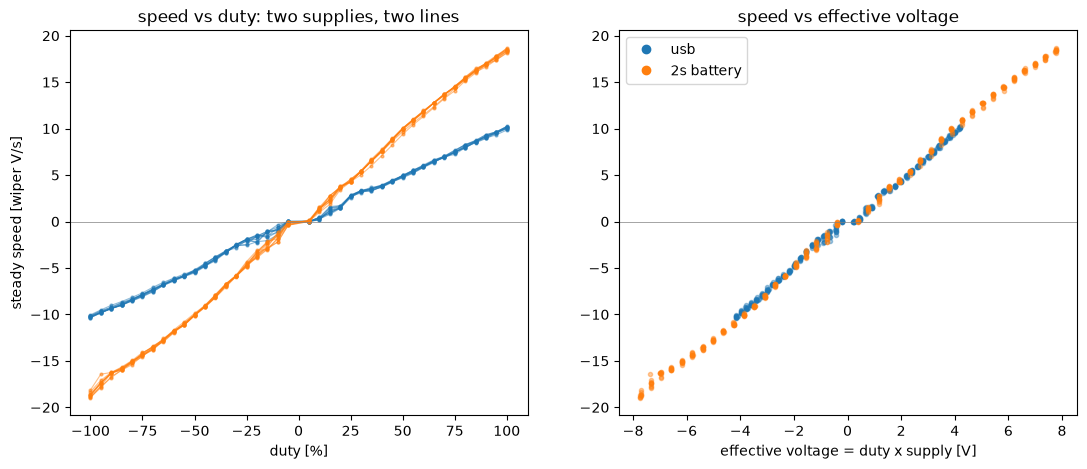

,slope_Vps_per_V,intercept_Vps,slope_vs_mean_pct
series,,,
usb,2.390,-0.096,-1.295
2s battery,2.453,-0.060,1.295


In [9]:
def step_speeds(df):
    sup = step_supply(df).set_index("duty_pct")["supply_V"]
    sup_lo = sup[np.abs(sup.index) <= 30].mean()
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        n = len(seg)
        tail = seg.iloc[int(n * 0.4):]
        t = (tail["tick"] - tail["tick"].iloc[0]) / TICK_HZ
        slope = np.polyfit(t, tail["pos"] * V_ADC_PER_COUNT, 1)[0]
        d = seg["duty_pct"].iloc[0]
        out.append({
            "duty_pct": d,
            "speed_Vps": slope,                       # wiper volts per second
            "supply_V": sup.get(d, sup_lo),
        })
    return pd.DataFrame(out)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for recs, color, label in [(usb, "tab:blue", "usb"),
                           (batt, "tab:orange", "2s battery")]:
    for name, (df, meta) in recs.items():
        sp = step_speeds(df).sort_values("duty_pct")
        axes[0].plot(sp["duty_pct"], sp["speed_Vps"], "-o", ms=2, lw=0.8,
                     alpha=0.5, color=color)
        veff = sp["duty_pct"] / 100.0 * sp["supply_V"]
        axes[1].plot(veff, sp["speed_Vps"], "o", ms=3, alpha=0.4, color=color)
    axes[1].plot([], [], "o", color=color, label=label)
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("steady speed [wiper V/s]")
axes[0].set_title("speed vs duty: two supplies, two lines")
axes[1].set_xlabel("effective voltage = duty x supply [V]")
axes[1].set_title("speed vs effective voltage")
axes[1].legend()
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
plt.show()

rows = []
for recs, label in [(usb, "usb"), (batt, "2s battery")]:
    pts = pd.concat([step_speeds(df) for df, _ in recs.values()])
    veff = pts["duty_pct"] / 100.0 * pts["supply_V"]
    m = veff.abs() > 1.0     # fit above 1 V, clear of the motion threshold
    k = np.polyfit(veff[m], pts["speed_Vps"][m], 1)
    rows.append({"series": label,
                 "slope_Vps_per_V": k[0],
                 "intercept_Vps": k[1]})
fits = pd.DataFrame(rows).set_index("series")
fits["slope_vs_mean_pct"] = (fits["slope_Vps_per_V"]
                             / fits["slope_Vps_per_V"].mean() - 1) * 100
fits.round(3)


Findings:

- Against duty (left panel), the two series form two distinct straight
  lines. The battery line is steeper by roughly the ratio of the supply
  voltages, so duty alone does not predict speed.
- Against effective voltage (right panel), the two series fall on one
  line. The fitted slopes agree to under 3% across the 4.5 V and 7.75 V
  supplies. The linear speed-voltage relationship of the brushed DC motor
  model holds in this data with no calibration involved.
- The per-step supply matters. With a single supply value per series the
  slopes disagree by 7%, most of it from the USB voltage drop. The
  remaining difference of under 3% is unexplained here and is taken up in
  the friction notebook.

### 6.4 Repeatability across recordings

Each series is ten identical recordings separated by reboots and
one-minute rests, so drift across recordings reflects the hardware. The
figure shows the steady speed of the +100% duty step for every recording,
in order.


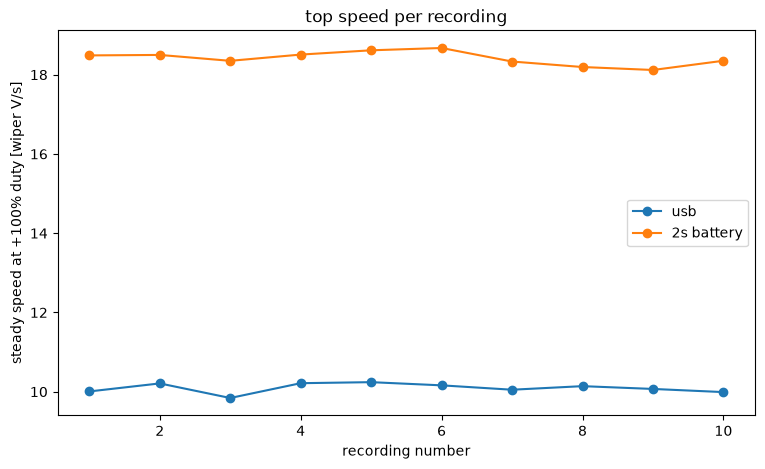

,spread_pct
series,
usb,4.0
2s battery,3.0


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for recs, color, label in [(usb, "tab:blue", "usb"),
                           (batt, "tab:orange", "2s battery")]:
    xs, ys = [], []
    for name, (df, meta) in recs.items():
        n = int(name.split("-")[1])
        sp = step_speeds(df)
        row = sp[np.isclose(sp["duty_pct"], 100.0, atol=0.1)]
        xs.append(n)
        ys.append(row["speed_Vps"].iloc[0])
    ax.plot(xs, ys, "-o", color=color, label=label)
    rows.append({"series": label,
                 "spread_pct": (max(ys) - min(ys)) / np.mean(ys) * 100})
ax.set_xlabel("recording number")
ax.set_ylabel("steady speed at +100% duty [wiper V/s]")
ax.set_title("top speed per recording")
ax.legend()
plt.show()
pd.DataFrame(rows).set_index("series").round(1)


The ten recordings of each series agree within 3 to 4% at full duty,
with no systematic trend standing out of the scatter. Plausible
contributors include thermal changes in the gear train and, on the battery
series, the slow discharge of the pack over the session. Neither is
isolated or tested here. Any single recording carries a few percent of
unexplained variation, so fits in later notebooks pool across recordings.

## 7. Limitations and open issues

- **One unit.** All numbers describe this one servo and this one board.
  The gear train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2).
- **Position linearity is not established.** The pot's voltage-vs-angle
  linearity is not measured here. Nothing in this notebook depends on it.
  Fits that combine distant regions of travel will have to address it.
- **80 ms drive steps are short.** High-duty steps reach steady speed well
  inside the window. The slowest moving steps are still accelerating when
  the window ends, so their fitted speeds read slightly low.
- **The validity thresholds are this board's.** The 20% and 25% sampling
  thresholds change with board revision.
- **Battery series exceeds the servo's usual rating.** The full-duty
  battery steps apply about 7.8 V to a mechanism usually rated 4.8 to 6 V.
- **Open investigation: corruption bursts.** During collection, roughly
  one recording in four contained a single burst of about 6 consecutive
  corrupted frames at a random position, on both supplies. The CRC caught
  every one and the affected recordings were discarded, so the accepted
  data is unaffected. The cause is not yet found.

## 8. Next notebooks

The same recordings support the next derivations, each one checked against
the firmware's on-servo computation:

- Winding resistance from the current and voltage of the stalled and
  low-speed steps.
- Back-EMF constant and friction from the moving steps, including the 0.39
  to 0.45 V motion threshold measured here.
- The firmware's supply estimator and current-offset handling, re-derived
  from this raw data and compared against the servo's live values.
